# Feature engineering

Building one row per account out of the transaction log - transaction
counts, amounts, and balance behavior. Every aggregate here is a plain
vectorized `groupby`, computed once. That's worth calling out explicitly:
a natural-looking way to write a running "how many times has this account
shown up so far" counter is a per-row loop over `str(series[0:i])` and a
regex match against that string - but `str()` on a pandas Series is a
*display* function, and past a few dozen rows it silently truncates to
just the head and tail for printing. Every count computed that way past
row ~60 would be counting substring matches inside a truncated, elided
string rather than the real history - the numbers would look plausible
and be almost entirely wrong. `groupby(...).transform(...)` (or
`cumcount()`) does the same job correctly, and about a million times
faster.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

account = pd.read_csv('data/account.asc', sep = ';')
card = pd.read_csv('data/card.asc', sep = ';')
client = pd.read_csv('data/client.asc', sep = ';')
disp = pd.read_csv('data/disp.asc', sep = ';')
loan = pd.read_csv('data/loan.asc', sep = ';')
order = pd.read_csv('data/order.asc', sep = ';')
trans = pd.read_csv('data/trans.asc', sep = ';', low_memory = False)

trans['amount_signed'] = np.where(trans['type'] == 'VYDAJ', -trans['amount'], trans['amount'])
trans.shape

(1056320, 11)

In [2]:
trans_features = trans.groupby('account_id').agg(
    n_transactions = ('trans_id', 'count'),
    mean_amount = ('amount', 'mean'),
    std_amount = ('amount', 'std'),
    max_amount = ('amount', 'max'),
    mean_balance = ('balance', 'mean'),
    min_balance = ('balance', 'min'),
    max_balance = ('balance', 'max'),
    std_balance = ('balance', 'std'),
    net_flow = ('amount_signed', 'sum'),
    n_withdrawals = ('type', lambda s: (s == 'VYDAJ').sum()),
    n_deposits = ('type', lambda s: (s == 'PRIJEM').sum()),
).reset_index()

trans_features['withdrawal_ratio'] = trans_features['n_withdrawals'] / trans_features['n_transactions']
trans_features['std_balance'] = trans_features['std_balance'].fillna(0)
trans_features['std_amount'] = trans_features['std_amount'].fillna(0)

trans_features.shape

(4500, 13)

Account tenure and transaction recency - both need the real chronology, not a count of *rows seen so far in file order*.

In [3]:
def parse_asc_date(series):
    return pd.to_datetime(series.astype(str), format = '%y%m%d')

account['open_date'] = parse_asc_date(account['date'])
trans['trans_date'] = parse_asc_date(trans['date'])

last_date_in_data = trans['trans_date'].max()

tenure = (last_date_in_data - account.set_index('account_id')['open_date']).dt.days.rename('tenure_days')
last_activity = trans.groupby('account_id')['trans_date'].max()
recency = (last_date_in_data - last_activity).dt.days.rename('days_since_last_transaction')

trans_features = trans_features.merge(tenure, on = 'account_id', how = 'left').merge(recency, on = 'account_id', how = 'left')
trans_features['days_since_last_transaction'] = trans_features['days_since_last_transaction'].fillna(trans_features['tenure_days'])
trans_features['transactions_per_month'] = trans_features['n_transactions'] / (trans_features['tenure_days'] / 30.44).clip(lower = 1)

trans_features[['tenure_days', 'days_since_last_transaction', 'transactions_per_month']].describe()

,tenure_days,days_since_last_transaction,transactions_per_month
count,4500.000000,4500.000000,4500.000000
mean,1240.931333,2.599111,5.635616
std,551.838706,30.625054,1.365175
min,367.000000,0.000000,0.318929
25%,790.000000,0.000000,4.840254
50%,1094.000000,0.000000,5.505916
75%,1830.000000,0.000000,6.365735
max,2190.000000,858.000000,11.739193


Standing orders (`order.asc`) and card/loan ownership add a few more account-level flags - again all via `groupby`/`merge`, not row-by-row loops.

In [4]:
order_features = order.groupby('account_id').agg(
    n_standing_orders = ('order_id', 'count'),
    total_order_amount = ('amount', 'sum'),
).reset_index()

has_card = card.merge(disp[['disp_id', 'account_id']], on = 'disp_id', how = 'left').groupby('account_id').size().rename('has_card')
has_loan = loan.groupby('account_id').size().rename('has_loan')

features = (
    account[['account_id', 'district_id', 'frequency']]
    .merge(trans_features, on = 'account_id', how = 'left')
    .merge(order_features, on = 'account_id', how = 'left')
    .merge(has_card, on = 'account_id', how = 'left')
    .merge(has_loan, on = 'account_id', how = 'left')
)
features['has_card'] = features['has_card'].fillna(0).gt(0).astype(int)
features['has_loan'] = features['has_loan'].fillna(0).gt(0).astype(int)
features['n_standing_orders'] = features['n_standing_orders'].fillna(0)
features['total_order_amount'] = features['total_order_amount'].fillna(0)

features.shape

(4500, 22)

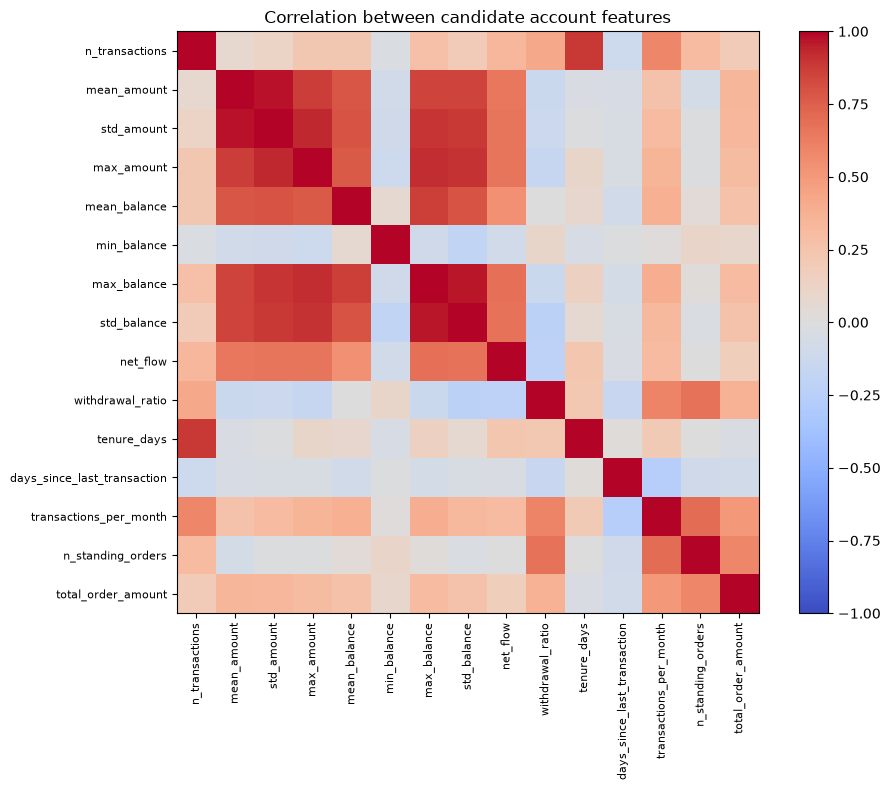

In [5]:
numeric_cols = [
    'n_transactions', 'mean_amount', 'std_amount', 'max_amount',
    'mean_balance', 'min_balance', 'max_balance', 'std_balance',
    'net_flow', 'withdrawal_ratio', 'tenure_days',
    'days_since_last_transaction', 'transactions_per_month',
    'n_standing_orders', 'total_order_amount',
]

fig, ax = plt.subplots(figsize = (10, 8))
corr = features[numeric_cols].corr()
im = ax.imshow(corr, cmap = 'coolwarm', vmin = -1, vmax = 1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation = 90, fontsize = 8)
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols, fontsize = 8)
plt.colorbar(im)
plt.title('Correlation between candidate account features')
plt.tight_layout()
plt.savefig('outputs/feature_correlation.png', dpi = 120)
plt.show()

`mean_balance` correlates strongly with `min_balance`/`max_balance` (all three measure roughly the same thing - how much money sits in the account) - keeping `mean_balance` and `std_balance` and dropping the other two avoids feeding near-duplicate information into the models that follow.

In [6]:
final_features = [
    'n_transactions', 'mean_amount', 'std_amount', 'max_amount',
    'mean_balance', 'std_balance', 'net_flow', 'withdrawal_ratio',
    'tenure_days', 'days_since_last_transaction', 'transactions_per_month',
    'n_standing_orders', 'total_order_amount', 'has_card',
]

features_clean = features[['account_id', 'has_loan'] + final_features].dropna()
features_clean.shape

(4500, 16)

In [7]:
os.makedirs('outputs', exist_ok = True)
features_clean.to_csv('outputs/account_features.csv', index = False)

with open('outputs/feature_list.json', 'w') as f:
    json.dump(final_features, f, indent = 2)

features_clean.describe().round(1)

,account_id,has_loan,n_transactions,mean_amount,std_amount,max_amount,mean_balance,std_balance,net_flow,withdrawal_ratio,tenure_days,days_since_last_transaction,transactions_per_month,n_standing_orders,total_order_amount,has_card
count,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0,4500.0
mean,2786.1,0.2,234.7,5757.7,6897.4,29619.0,36667.9,12979.9,136524.2,0.6,1240.9,2.6,5.6,1.4,4717.6,0.2
std,2313.8,0.4,126.8,4030.5,4789.3,20030.4,15165.6,7929.3,215560.4,0.1,551.8,30.6,1.4,1.1,4039.2,0.4
min,1.0,0.0,9.0,843.4,981.7,2901.0,5711.3,1946.8,-25821.0,0.1,367.0,0.0,0.3,0.0,0.0,0.0
25%,1182.8,0.0,133.0,2303.2,2461.9,11500.0,23570.9,6412.8,24959.9,0.5,790.0,0.0,4.8,1.0,2071.8,0.0
50%,2368.0,0.0,208.0,4729.7,5930.4,26500.0,34696.5,11175.5,47485.7,0.6,1094.0,0.0,5.5,1.0,3594.5,0.0
75%,3552.2,0.0,330.0,8352.2,10222.1,45691.8,47818.7,17155.0,99437.1,0.6,1830.0,0.0,6.4,2.0,6951.0,0.0
max,11382.0,1.0,675.0,21062.6,22971.8,87400.0,81192.8,37690.4,1589614.0,0.8,2190.0,858.0,11.7,5.0,22704.3,1.0
